# 02 Logistic Regression - Email Spam Classification

This is a complete, standalone pipeline for training a Logistic Regression model on dirty email data. It handles everything from HTML stripping to model persistence.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import re
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

sns.set(style='whitegrid')

### 1. Data Cleaning & Preprocessing
We standardize column names to lowercase, remove duplicates, and strip HTML tags from the message content.

In [2]:
df = pd.read_csv('../_data/email_spam.csv')
df.columns = [c.lower().replace('-', '_').replace(' ', '_') for c in df.columns]
df = df.drop_duplicates()

def clean_text(text):
    # Remove HTML tags using Regex
    text = re.sub('<.*?>', '', str(text))
    return text.strip().lower()

df['text_clean'] = df['message_content'].apply(clean_text)
df['is_spam'] = df['target_label'].apply(lambda x: 1 if str(x).lower().strip() in ['1', 'spam', 's_p_a_m'] else 0)

X_train, X_test, y_train, y_test = train_test_split(df['text_clean'], df['is_spam'], test_size=0.2, random_state=42)

### 2. Pipeline Building & Training
We use a Scikit-Learn Pipeline to wrap the TF-IDF vectorizer and the Logistic Regression model together.

In [3]:
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words='english', max_features=5000)),
    ('clf', LogisticRegression(class_weight='balanced'))
])

pipeline.fit(X_train, y_train)
print("Model training complete.")

Model training complete.


### 3. Evaluation & Visualization
We generate a Confusion Matrix and an ROC Curve to verify model performance.

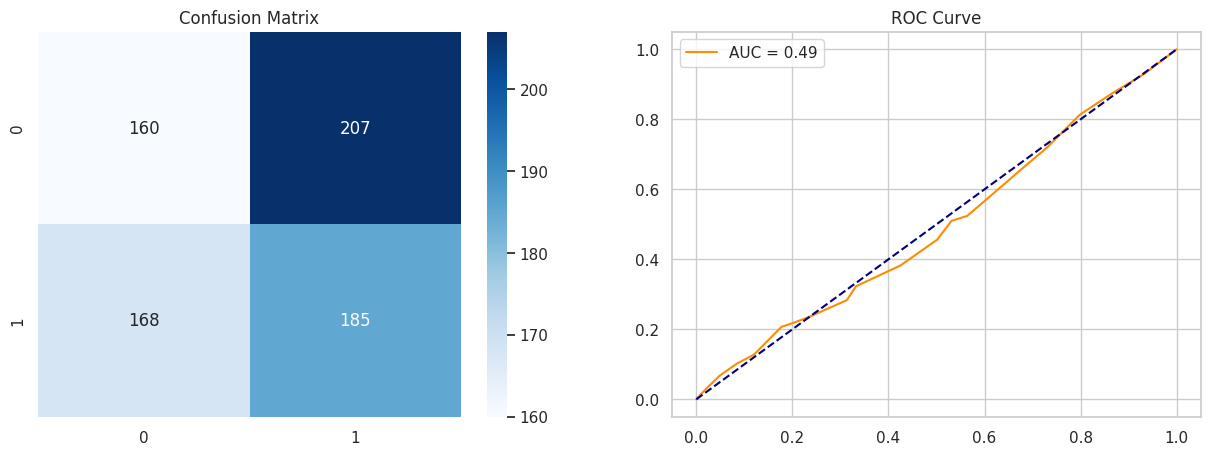

              precision    recall  f1-score   support

           0       0.49      0.44      0.46       367
           1       0.47      0.52      0.50       353

    accuracy                           0.48       720
   macro avg       0.48      0.48      0.48       720
weighted avg       0.48      0.48      0.48       720



In [4]:
y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1]

fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# Confusion Matrix
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', ax=ax[0])
ax[0].set_title('Confusion Matrix')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
ax[1].plot(fpr, tpr, color='darkorange', label=f'AUC = {auc(fpr, tpr):.2f}')
ax[1].plot([0, 1], [0, 1], color='navy', linestyle='--')
ax[1].set_title('ROC Curve')
ax[1].legend()
plt.show()

print(classification_report(y_test, y_pred))

### 4. Model Persistence
Saving the full pipeline to the model folder.

In [5]:
joblib.dump(pipeline, '../_model/email_classification_logistic_regression.joblib')
print("Pipeline saved to src/ml/_model/")

Pipeline saved to src/ml/_model/
